In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [22]:
df_rockyPoint = pd.read_csv('./input/ACT2781_1_Annual_2026.csv')
df_rockyPoint.columns = df_rockyPoint.columns.str.strip()
df_rockyPoint['Speed (m/s)'] = pd.to_numeric(df_rockyPoint['Speed (cm/sec)'], errors='coerce') / 100

In [23]:
df_cornfieldPoint = pd.read_csv('./input/LIS1016_17_Annual_2026.csv')
df_cornfieldPoint.columns = df_cornfieldPoint.columns.str.strip()
df_cornfieldPoint['Speed (m/s)'] = pd.to_numeric(df_cornfieldPoint['Speed (cm/sec)'], errors='coerce') / 100

In [24]:
df_mulfordPoint = pd.read_csv('./input/ACT2776_1_Annual_2026.csv')
df_mulfordPoint.columns = df_mulfordPoint.columns.str.strip()
df_mulfordPoint['Speed (m/s)'] = pd.to_numeric(df_mulfordPoint['Speed (cm/sec)'], errors='coerce') / 100

In [25]:
df_rockyPoint.head()

,Date_Time (GMT),Event,Speed (cm/sec),Speed (m/s)
0,2026-01-01 12:59 AM,slack,-,NaN
1,2026-01-01 04:12 AM,ebb,-101,-1.01
2,2026-01-01 07:45 AM,slack,-,NaN
3,2026-01-01 09:59 AM,flood,93,0.93
4,2026-01-01 01:18 PM,slack,-,NaN


In [26]:
df_cornfieldPoint.head()

,Date_Time (LST_LDT),Event,Speed (cm/sec),Speed (m/s)
0,2026-01-01 12:07 AM,ebb,-114,-1.14
1,2026-01-01 03:12 AM,slack,-,NaN
2,2026-01-01 06:16 AM,flood,106,1.06
3,2026-01-01 09:12 AM,slack,-,NaN
4,2026-01-01 12:40 PM,ebb,-135,-1.35


In [27]:
df_mulfordPoint.head()

,Date_Time (LST_LDT),Event,Speed (cm/sec),Speed (m/s)
0,2026-01-01 03:06 AM,slack,-,NaN
1,2026-01-01 04:56 AM,flood,112,1.12
2,2026-01-01 09:14 AM,slack,-,NaN
3,2026-01-01 11:48 AM,ebb,-126,-1.26
4,2026-01-01 04:02 PM,slack,-,NaN


Rocky Point: upward zero-crossings=704, cycles kept=703
Rocky Point: cosine fit amplitude=0.593 m/s, phase_shift≈-90.1°


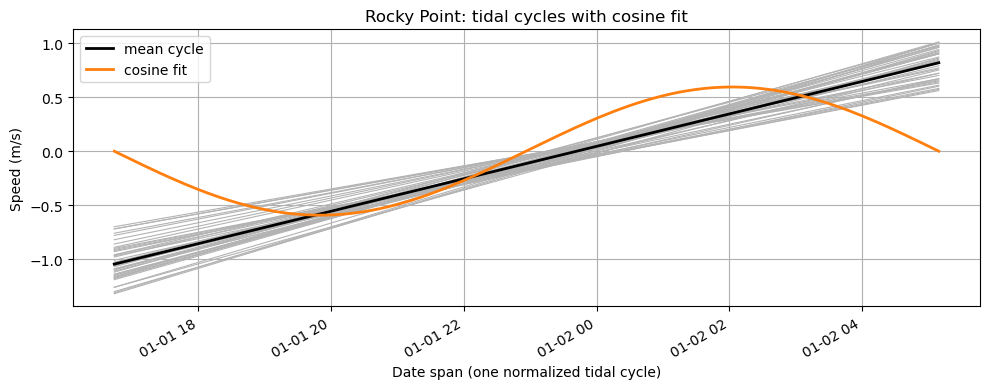

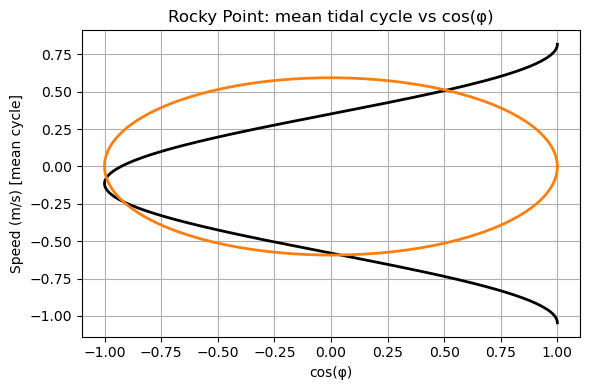

Cornfield Point: upward zero-crossings=704, cycles kept=703
Cornfield Point: cosine fit amplitude=0.684 m/s, phase_shift≈-90.1°


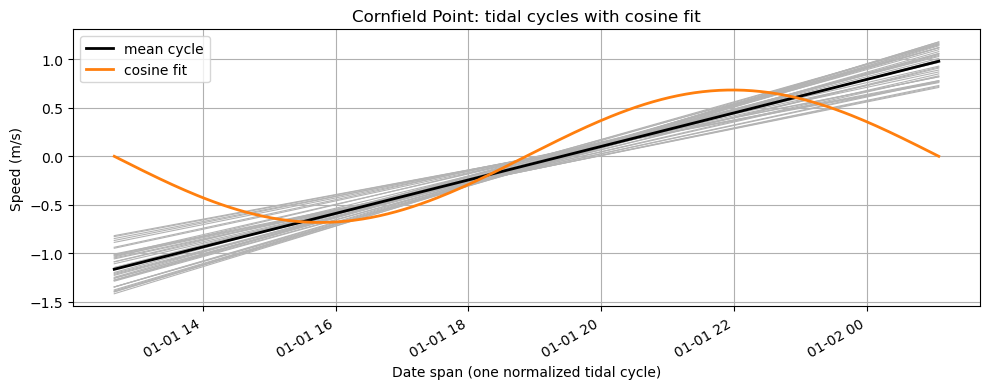

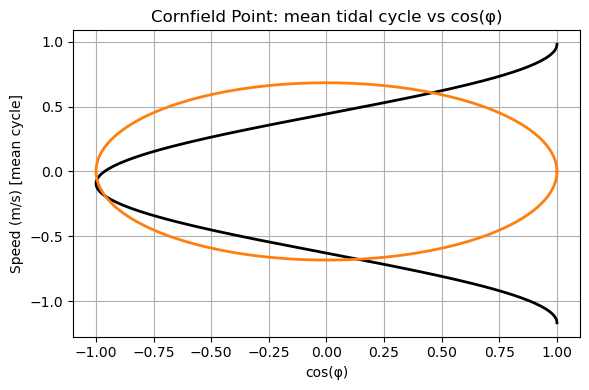

Mulford Point: upward zero-crossings=704, cycles kept=703
Mulford Point: cosine fit amplitude=0.645 m/s, phase_shift≈-90.0°


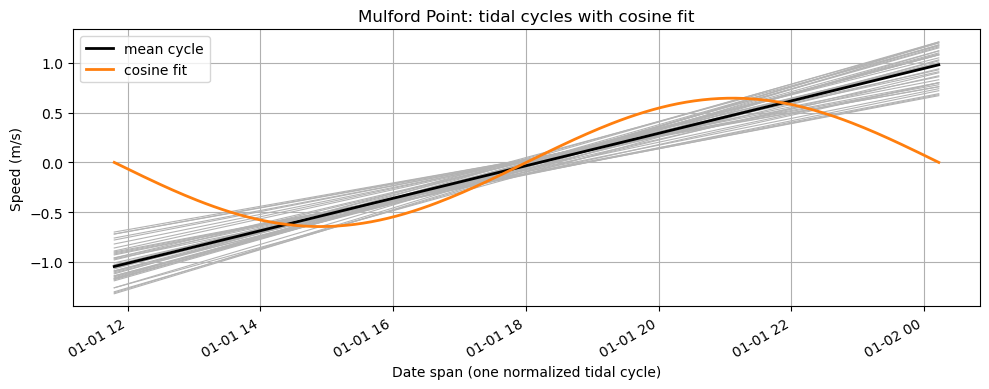

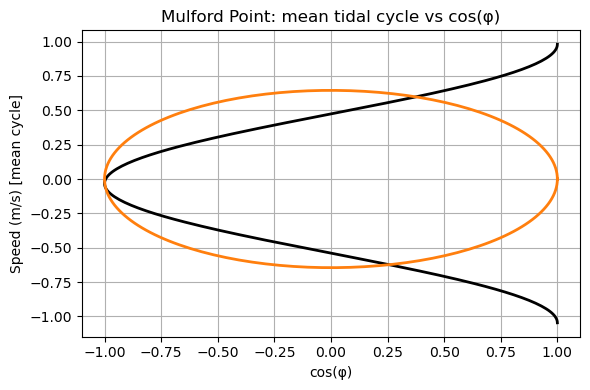

In [31]:
# --- build full tidal cycles for each dataframe and plot in date-span/cosine form ---
def _find_upward_zero_crossings(u_signed):
    """Return indices i where u[i] <= 0 and u[i+1] > 0 (upward crossing)."""
    u = np.asarray(u_signed, dtype=float)
    idx = []
    for i in range(len(u) - 1):
        if np.isfinite(u[i]) and np.isfinite(u[i + 1]) and (u[i] <= 0) and (u[i + 1] > 0):
            idx.append(i)
    return np.array(idx, dtype=int)

def _plot_tidal_cycles_for_df(df, label, time_col=None):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if time_col is None:
        time_candidates = [c for c in df.columns if c.startswith('Date_Time')]
        if not time_candidates:
            raise KeyError(f'No Date_Time column found for {label}')
        time_col = time_candidates[0]

    speed_col = 'Speed (m/s)' if 'Speed (m/s)' in df.columns else 'Speed (cm/sec)'
    speed = pd.to_numeric(df[speed_col], errors='coerce')
    if speed_col == 'Speed (cm/sec)':
        speed = speed / 100.0

    t = pd.to_datetime(df[time_col], format='%Y-%m-%d %I:%M %p', errors='coerce')
    valid = t.notna() & speed.notna()
    t = t.loc[valid].reset_index(drop=True)
    speed = speed.loc[valid].reset_index(drop=True)
    if len(speed) < 20:
        print(f'{label}: not enough valid points to plot tidal cycles.')
        return

    smooth_n = 3
    u_for_cycles = speed.rolling(window=smooth_n, center=True, min_periods=1).mean().to_numpy()
    cross = _find_upward_zero_crossings(u_for_cycles)
    cycles = []
    for a, b in zip(cross[:-1], cross[1:]):
        i0 = a + 1
        i1 = b + 1
        if i1 - i0 < 2:
            continue
        dur_hr = (t.iloc[i1] - t.iloc[i0]).total_seconds() / 3600.0
        if (dur_hr < 0.5) or (dur_hr > 24):
            continue
        cycles.append((i0, i1, dur_hr))

    print(f'{label}: upward zero-crossings={len(cross)}, cycles kept={len(cycles)}')
    if not cycles:
        plt.figure(figsize=(10, 4))
        plt.plot(t, speed, color='C0', linewidth=1)
        plt.xlabel('Time')
        plt.ylabel('Speed (m/s)')
        plt.title(f'{label}: speed time series')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        return

    n_phase = 200
    phi_grid = np.linspace(0, 2 * np.pi, n_phase)
    U_mat = np.full((len(cycles), n_phase), np.nan)
    for k, (i0, i1, dur_hr) in enumerate(cycles):
        tseg = t.iloc[i0:i1].astype('int64').to_numpy(dtype=float)
        tseg = (tseg - tseg[0]) / (tseg[-1] - tseg[0])
        useg = speed.iloc[i0:i1].to_numpy(dtype=float)
        good = np.isfinite(useg) & np.isfinite(tseg)
        if good.sum() < 2:
            continue
        U_mat[k, :] = np.interp(phi_grid / (2 * np.pi), tseg[good], useg[good])

    U_mean = np.nanmean(U_mat, axis=0)
    A = np.vstack([np.cos(phi_grid), np.sin(phi_grid)]).T
    goodm = np.isfinite(U_mean)
    coef, *_ = np.linalg.lstsq(A[goodm], U_mean[goodm], rcond=None)
    a, b = float(coef[0]), float(coef[1])
    U_fit = a * np.cos(phi_grid) + b * np.sin(phi_grid)
    amp = math.hypot(a, b)
    phase_shift = math.degrees(math.atan2(b, a))
    print(f'{label}: cosine fit amplitude={amp:.3f} m/s, phase_shift≈{phase_shift:.1f}°')

    mean_cycle_hr = float(np.nanmean([c[2] for c in cycles]))
    span_start = t.iloc[cycles[0][0]]
    span_end = span_start + pd.to_timedelta(mean_cycle_hr, unit='h')
    t_span = pd.date_range(span_start, span_end, periods=n_phase)

    plt.figure(figsize=(10, 4))
    for k in range(min(U_mat.shape[0], 40)):
        plt.plot(t_span, U_mat[k, :], color='0.7', linewidth=0.8)
    plt.plot(t_span, U_mean, color='k', linewidth=2, label='mean cycle')
    plt.plot(t_span, U_fit, color='C1', linewidth=2, label='cosine fit')
    plt.xlabel('Date span (one normalized tidal cycle)')
    plt.ylabel('Speed (m/s)')
    plt.title(f'{label}: tidal cycles with cosine fit')
    plt.grid(True)
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(np.cos(phi_grid), U_mean, color='k', linewidth=2)
    plt.plot(np.cos(phi_grid), U_fit, color='C1', linewidth=2)
    plt.xlabel('cos(φ)')
    plt.ylabel('Speed (m/s) [mean cycle]')
    plt.title(f'{label}: mean tidal cycle vs cos(φ)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

_plot_tidal_cycles_for_df(df_rockyPoint, 'Rocky Point', time_col='Date_Time (GMT)')
_plot_tidal_cycles_for_df(df_cornfieldPoint, 'Cornfield Point', time_col='Date_Time (LST_LDT)')
_plot_tidal_cycles_for_df(df_mulfordPoint, 'Mulford Point', time_col='Date_Time (LST_LDT)')